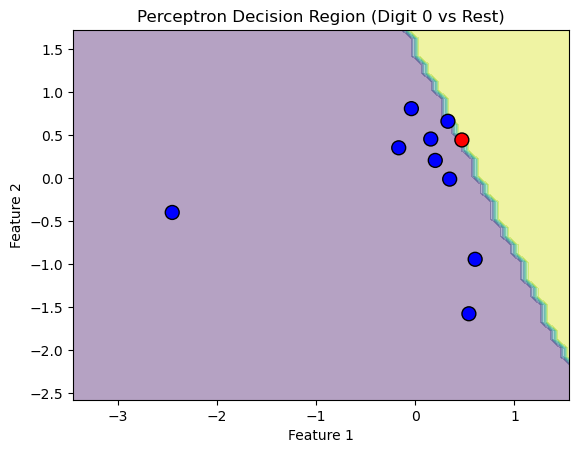

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 5x3 digit dataset (15 features)
X = np.array([
    [1,1,1, 1,0,1, 1,0,1, 1,0,1, 1,1,1],  # 0
    [0,1,0, 1,1,0, 0,1,0, 0,1,0, 1,1,1],  # 1
    [1,1,1, 0,0,1, 1,1,1, 1,0,0, 1,1,1],  # 2
    [1,1,1, 0,0,1, 1,1,1, 0,0,1, 1,1,1],  # 3
    [1,0,1, 1,0,1, 1,1,1, 0,0,1, 0,0,1],  # 4
    [1,1,1, 1,0,0, 1,1,1, 0,0,1, 1,1,1],  # 5
    [1,1,1, 1,0,0, 1,1,1, 1,0,1, 1,1,1],  # 6
    [1,1,1, 0,0,1, 0,0,1, 0,0,1, 0,0,1],  # 7
    [1,1,1, 1,0,1, 1,1,1, 1,0,1, 1,1,1],  # 8
    [1,1,1, 1,0,1, 1,1,1, 0,0,1, 1,1,1]   # 9
])

# Convert to binary classification (digit 0 vs rest)
y = np.where(np.arange(10) == 0, 1, -1)

# Reduce to 2D using PCA
pca = PCA(n_components=2)
X = pca.fit_transform(X)

# Initialize weights
w = np.zeros(X.shape[1])
b = 0

# Perceptron function (same as your code)
def perceptron(X, y, w, b, lr=0.1, epochs=100):
    for _ in range(epochs):
        for i in range(len(X)):
            z = np.dot(X[i], w) + b
            y_pred = 1 if z >= 0 else -1

            if y_pred != y[i]:
                w = w + lr * y[i] * X[i]
                b = b + lr * y[i]
    return w, b

# Train model
w, b = perceptron(X, y, w, b)

# ----- DECISION REGION (same style as your image code) -----

# Mesh grid
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# Predict grid
Z = np.sign(np.dot(np.c_[xx.ravel(), yy.ravel()], w) + b)
Z = Z.reshape(xx.shape)

# Plot decision region
plt.contourf(xx, yy, Z, alpha=0.4)

# Plot data points
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', s=100, edgecolors='k')

plt.title("Perceptron Decision Region (Digit 0 vs Rest)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()